# Week 9 수업 예제: Perceptron과 MLP

이 노트북은 **수업 중 강사와 함께 실행**하는 예제입니다.
각 셀을 순서대로 실행하며 강의 내용을 체험하세요.

## 준비

같은 폴더에 `perceptron.py` 파일이 있어야 합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from perceptron import Perceptron, MultiLayerPerceptron



---
## AND 연산을 Perceptron으로 학습

In [2]:
# AND 학습 데이터
X = np.array([[-1, -1],
              [-1,  1],
              [ 1, -1],
              [ 1,  1]])
y = np.array([-1, -1, -1, 1])

# Perceptron 생성 및 학습
p = Perceptron(n_inputs=2, learning_rate=0.1)
p.fit(X, y, epochs=20, verbose=True)

print(f"\n학습된 가중치: w = {p.w}, b = {p.b:.3f}")

Epoch 1: errors=1, w=[0.2 0.2], b=0.200
Epoch 2: errors=2, w=[0.2 0.2], b=-0.200
Epoch 3: errors=0, w=[0.2 0.2], b=-0.200
Converged at epoch 3

학습된 가중치: w = [0.2 0.2], b = -0.200


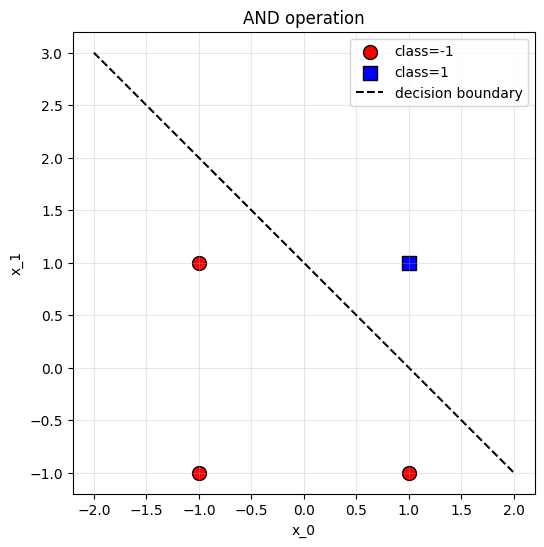

In [9]:
# 결정 경계 시각화
p.plot_decision_boundary(X, y, title="AND operation")
plt.show()

---
## 예제 2: OR, NAND도 같은 방식으로

같은 Perceptron 클래스로 OR와 NAND도 학습할 수 있습니다. 입력은 그대로 두고 타겟만 바꿉니다.

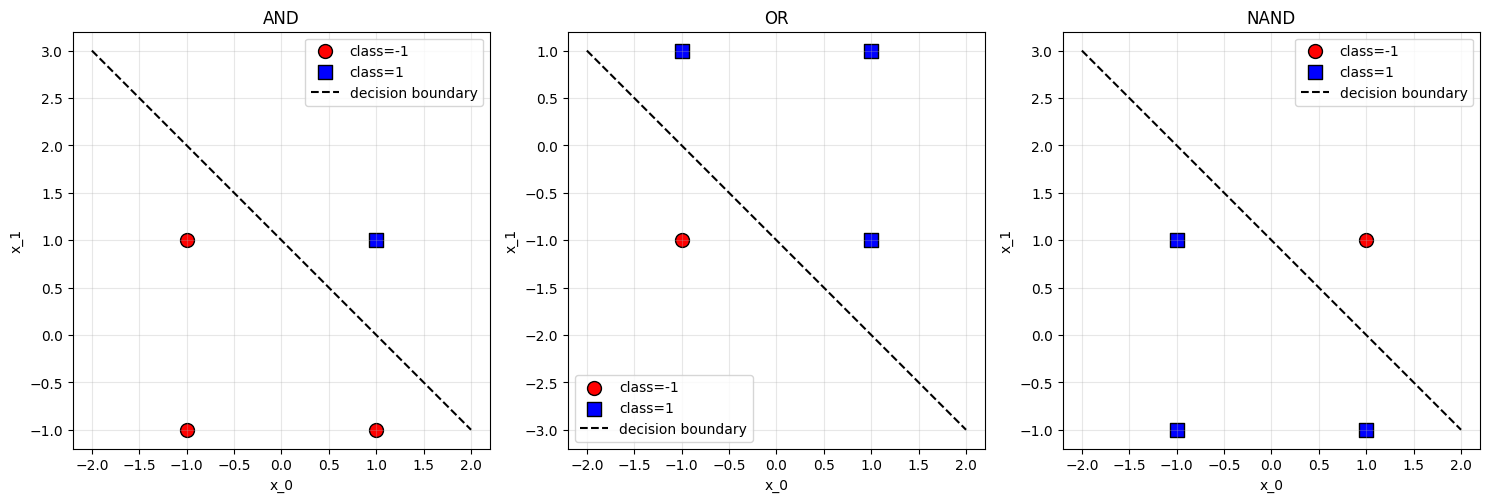

AND:  w=[0.2 0.2],  b=-0.20
OR:   w=[0.2 0.2],  b=0.20
NAND: w=[-0.2 -0.2],  b=0.20


In [4]:
# OR
y_or = np.array([-1, 1, 1, 1])
p_or = Perceptron(n_inputs=2, learning_rate=0.1)
p_or.fit(X, y_or, epochs=20)

# NAND
y_nand = np.array([1, 1, 1, -1])
p_nand = Perceptron(n_inputs=2, learning_rate=0.1)
p_nand.fit(X, y_nand, epochs=20)

# 세 결과를 나란히 표시
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p.plot_decision_boundary(X, y, title="AND", ax=axes[0])
p_or.plot_decision_boundary(X, y_or, title="OR", ax=axes[1])
p_nand.plot_decision_boundary(X, y_nand, title="NAND", ax=axes[2])
plt.tight_layout()
plt.show()

print(f"AND:  w={p.w},  b={p.b:.2f}")
print(f"OR:   w={p_or.w},  b={p_or.b:.2f}")
print(f"NAND: w={p_nand.w},  b={p_nand.b:.2f}")

---
## 예제 3: XOR 학습 시도 - 실패의 확인

**수업 슬라이드 11-13과 대응**

같은 perceptron 클래스에 XOR 데이터를 넣으면 어떻게 될까요?

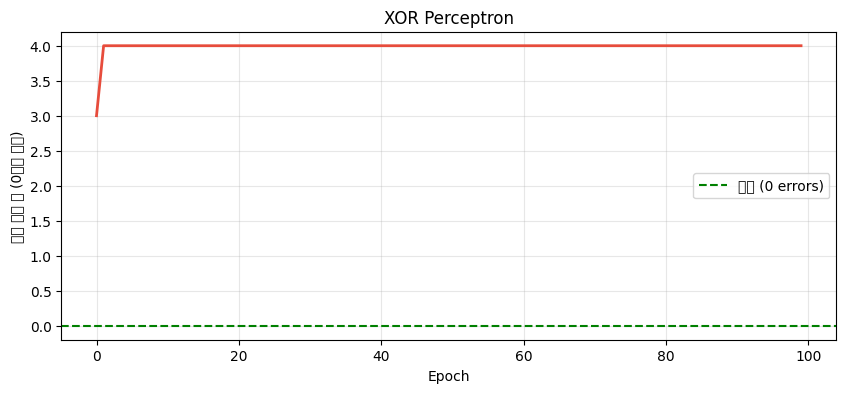

최종 에러 수: 4/4 (수렴 실패)


In [17]:
y_xor = np.array([-1, 1, 1, -1])

p_xor = Perceptron(n_inputs=2, learning_rate=0.5)
# 100 epoch 돌려봐도 수렴하지 않습니다
p_xor.fit(X, y_xor, epochs=100)

# 에러 히스토리 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(p_xor.history['loss'], color='#E74C3C', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("틀린 샘플 수 (0이면 수렴)")
ax.set_title("XOR Perceptron")
ax.axhline(0, color='green', linestyle='--', label='목표 (0 errors)')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

print(f"최종 에러 수: {p_xor.history['loss'][-1]}/4 (수렴 실패)")

---
## 예제 4: MLP로 XOR 해결 (가중치 하드코딩)

**수업 슬라이드 14-18과 대응**

여러 perceptron을 조합하면 XOR를 풀 수 있습니다. 
`XOR(x₁, x₂) = AND(NAND(x₁, x₂), OR(x₁, x₂))`

**주의**: 여기서는 가중치를 학습이 아니라 **손으로** 설정합니다. 

In [6]:
mlp = MultiLayerPerceptron.xor_hardcoded()

print("MLP로 XOR 계산:")
print("-" * 40)
for x in X:
    pred = mlp.predict(x)[0]
    target = y_xor[np.where((X == x).all(axis=1))[0][0]]
    mark = "✓" if pred == target else "✗"
    print(f"  XOR({x[0]:+d}, {x[1]:+d}) = {pred:+d}   (정답: {target:+d}) {mark}")

MLP로 XOR 계산:
----------------------------------------
  XOR(-1, -1) = -1   (정답: -1) ✓
  XOR(-1, +1) = +1   (정답: +1) ✓
  XOR(+1, -1) = +1   (정답: +1) ✓
  XOR(+1, +1) = -1   (정답: -1) ✓


In [7]:
# 하드코딩된 가중치를 직접 살펴봅시다
print("각 게이트의 가중치:")
print(f"  OR:   w = {mlp.perceptrons['or'].w},  b = {mlp.perceptrons['or'].b}")
print(f"  NAND: w = {mlp.perceptrons['nand'].w},  b = {mlp.perceptrons['nand'].b}")
print(f"  AND:  w = {mlp.perceptrons['and'].w},  b = {mlp.perceptrons['and'].b}")

각 게이트의 가중치:
  OR:   w = [0.5 0.5],  b = 0.7
  NAND: w = [-0.5 -0.5],  b = 0.7
  AND:  w = [0.5 0.5],  b = -0.7


---
## 예제 5: Hidden Layer가 공간을 어떻게 변환하는가


C:\Users\yongo\AppData\Local\Temp\ipykernel_12344\1846021077.py:35: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yongo\AppData\Local\Temp\ipykernel_12344\1846021077.py:35: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yongo\AppData\Local\Temp\ipykernel_12344\1846021077.py:35: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yongo\AppData\Local\Temp\ipykernel_12344\1846021077.py:35: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yongo\AppData\Local\Temp\ipykernel_12344\1846021077.py:35: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yongo\AppData\Local\Temp\ipykernel_12344\1846021077.py:35: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing

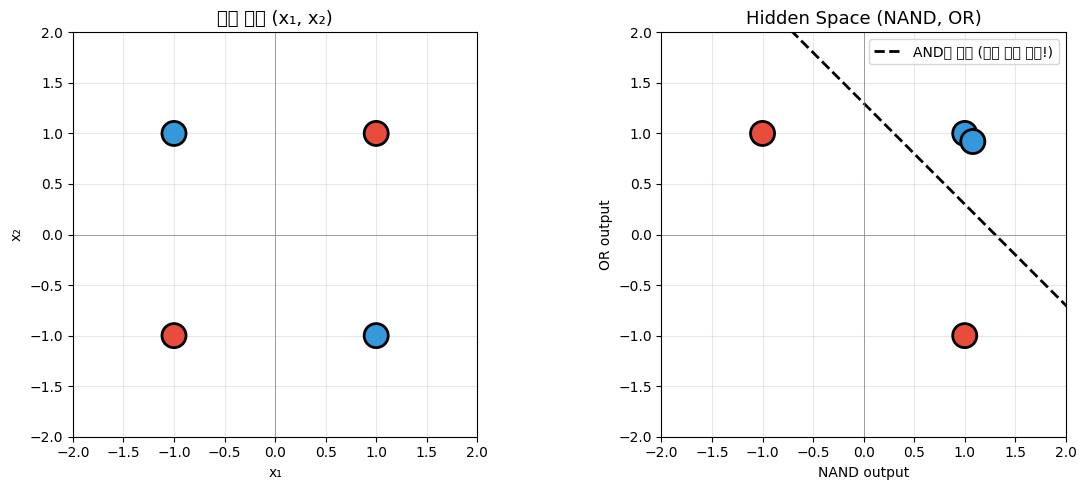

In [18]:
# 원래 공간과 hidden 공간을 동시에 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#E74C3C' if l == -1 else '#3498DB' for l in y_xor]

# 원래 공간
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=300, edgecolor='black', linewidth=2, zorder=5)
ax.set_title("원래 공간 (x₁, x₂)", fontsize=13)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# Hidden 공간: NAND와 OR의 출력
ax = axes[1]
hidden = np.array([[mlp.perceptrons['nand'].predict(x)[0],
                     mlp.perceptrons['or'].predict(x)[0]] for x in X])
# 중복 점들을 살짝 흩뜨리기
offset = np.array([[0,0],[0,0],[0.08,-0.08],[0,0]])
ax.scatter(hidden[:,0] + offset[:,0], hidden[:,1] + offset[:,1],
           c=colors, s=300, edgecolor='black', linewidth=2, zorder=5)

# 선형 분리기 예시
xs = np.linspace(-2.5, 2.5, 100)
ax.plot(xs, -xs + 1.3, 'k--', linewidth=2, label='AND의 경계 (선형 분리 가능!)')

ax.set_title("Hidden Space (NAND, OR)", fontsize=13)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_xlabel('NAND output'); ax.set_ylabel('OR output')
ax.legend()

plt.tight_layout()
plt.show()